In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.utils import open_icechunk

In [2]:
import os

import frisky
from distributed import Client

os.environ["FRISKY_SUMMARY"] = "off"

client = frisky.hijack(Client(n_workers=16))
client

<frisky.Client: scheduler="127.0.0.1:36937" id="client-0">

In [3]:
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"

In [4]:
var = "pr"
ssp_ens = "008"
g6_ens = "003"
hist_ens = "r3i1p1f1"

# Get data

In [5]:
# Coarse debiased data

coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

coarse_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/historical/" + var + "/" + hist_ens,
)[var]

coarse_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [6]:
# Downscaled, debiased data
ds_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="ssp245/" + var + "/" + ssp_ens,
)[var]

ds_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="historical/" + var + "/" + hist_ens,
)[var]

ds_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [7]:
# Raw data
raw_data = catalog.get("CESM2-WACCM").to_xarray()
raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=ssp_ens)
raw_historical = raw_data["historical"][var].sel(ensemble_member=hist_ens)
raw_g6 = raw_data["g6_1p5k"][var].sel(ensemble_member=g6_ens)

# Process data

In [8]:
slice_hist = slice("1978-01-01", "2014-12-31")
slice_fut = slice("2040-01-01", "2069-12-31")
conv_to_mm_yr = 86400 * 365

In [9]:
def calculate_aggregate_stat(da, time_slice, agg_method="mean", unit_conv=conv_to_mm_yr):
    if agg_method == "mean":
        da_agg = da.sel(time=time_slice).mean(dim="time") * unit_conv
    return da_agg

In [10]:
coarse_debiased_historical_avg = calculate_aggregate_stat(
    da=coarse_debiased_historical, time_slice=slice_hist
).compute()
coarse_debiased_ssp_avg = calculate_aggregate_stat(
    da=coarse_debiased_ssp, time_slice=slice_fut
).compute()
coarse_debiased_g6_avg = calculate_aggregate_stat(
    da=coarse_debiased_g6, time_slice=slice_fut
).compute()

ds_debiased_historical_avg = calculate_aggregate_stat(
    da=ds_debiased_historical, time_slice=slice_hist
).compute()
ds_debiased_ssp_avg = calculate_aggregate_stat(da=ds_debiased_ssp, time_slice=slice_fut).compute()
ds_debiased_g6_avg = calculate_aggregate_stat(da=ds_debiased_g6, time_slice=slice_fut).compute()

raw_historical_avg = calculate_aggregate_stat(da=raw_historical, time_slice=slice_hist).compute()
raw_ssp_avg = calculate_aggregate_stat(da=raw_ssp, time_slice=slice_fut).compute()
raw_g6_avg = calculate_aggregate_stat(da=raw_g6, time_slice=slice_fut).compute()

In [11]:
coarsened_ds_debiased_historical_avg = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=ds_debiased_historical_avg, da_coarse_grid=raw_historical_avg
).compute()

coarsened_ds_debiased_ssp_avg = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=ds_debiased_ssp_avg, da_coarse_grid=raw_historical_avg
).compute()

coarsened_ds_debiased_g6_avg = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=ds_debiased_g6_avg, da_coarse_grid=raw_historical_avg
).compute()

In [12]:
coarse_debiased_delta_ssp_hist = (
    coarse_debiased_ssp_avg - coarse_debiased_historical_avg
).compute()
ds_debiased_delta_ssp_hist = (ds_debiased_ssp_avg - ds_debiased_historical_avg).compute()
coarsened_ds_debiased_delta_ssp_hist = (
    coarsened_ds_debiased_ssp_avg - coarsened_ds_debiased_historical_avg
).compute()
raw_delta_ssp_hist = (raw_ssp_avg - raw_historical_avg).compute()

coarse_debiased_delta_g6_ssp = (coarse_debiased_g6_avg - coarse_debiased_ssp_avg).compute()
ds_debiased_delta_g6_ssp = (ds_debiased_g6_avg - ds_debiased_ssp_avg).compute()
coarsened_ds_debiased_delta_g6_ssp = (
    coarsened_ds_debiased_g6_avg - coarsened_ds_debiased_ssp_avg
).compute()
raw_delta_g6_ssp = (raw_g6_avg - raw_ssp_avg).compute()

In [21]:
coarse_debiased_delta_ssp_hist_pct = (
    coarse_debiased_delta_ssp_hist * 100 / coarse_debiased_historical_avg
).compute()
ds_debiased_delta_ssp_hist_pct = (
    ds_debiased_delta_ssp_hist * 100 / ds_debiased_historical_avg
).compute()
coarsened_ds_debiased_delta_ssp_hist_pct = (
    coarsened_ds_debiased_delta_ssp_hist * 100 / coarsened_ds_debiased_historical_avg
).compute()
raw_delta_ssp_hist_pct = (raw_delta_ssp_hist * 100 / raw_historical_avg).compute()

coarse_debiased_delta_g6_ssp_pct = (
    coarse_debiased_delta_g6_ssp * 100 / coarse_debiased_ssp_avg
).compute()
ds_debiased_delta_g6_ssp_pct = (ds_debiased_delta_g6_ssp * 100 / ds_debiased_ssp_avg).compute()
coarsened_ds_debiased_delta_g6_ssp_pct = (
    coarsened_ds_debiased_delta_g6_ssp * 100 / coarsened_ds_debiased_ssp_avg
).compute()
raw_delta_g6_ssp_pct = (raw_delta_g6_ssp * 100 / raw_ssp_avg).compute()

# Make graphs

## Shared functions

In [14]:
def format_subplot(ax):
    ax.coastlines(linewidth=0.1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.1)


proj = ccrs.PlateCarree()

In [71]:
def plot_all_deltas(deltas_dict, suptitle, vmax=500, cbar_label="mm/day"):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15), subplot_kw={"projection": proj})
    cbar_kwargs = {"orientation": "horizontal", "pad": 0.05, "shrink": 0.8, "label": cbar_label}

    ax = axes[0, 0]
    (deltas_dict["raw"]).plot(ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs)
    format_subplot(ax)
    ax.set_title("Raw")

    ax = axes[0, 1]
    (deltas_dict["downscaled_debiased"]).plot(ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs)
    format_subplot(ax)
    ax.set_title("Downscaled debiased")

    ax = axes[1, 0]
    (deltas_dict["coarse_debiased"]).plot(ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs)
    format_subplot(ax)
    ax.set_title("Coarse debiased")

    ax = axes[1, 1]
    (deltas_dict["coarsened_downscaled_debiased"]).plot(ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs)
    format_subplot(ax)
    ax.set_title("Coarsened downscaled debiased")

    plt.suptitle(suptitle, fontsize=20)
    plt.tight_layout()

In [72]:
def plot_delta_distortions(deltas_dict, suptitle, vmax=500, cbar_label="mm/day"):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15), subplot_kw={"projection": proj})
    cbar_kwargs = {"orientation": "horizontal", "pad": 0.05, "shrink": 0.8}

    ax = axes[0, 0]
    (deltas_dict["coarse_debiased"] - deltas_dict["raw"]).plot(
        ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs
    )
    format_subplot(ax)
    ax.set_title("Coarse debiased - Raw")

    ax = axes[0, 1]
    (deltas_dict["coarsened_downscaled_debiased"] - deltas_dict["raw"]).plot(
        ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs
    )
    format_subplot(ax)
    ax.set_title("Coarsened downscaled debiased - Raw")

    axes[1, 0].set_visible(False)  # leave bottom-left empty

    ax = axes[1, 1]
    (deltas_dict["coarsened_downscaled_debiased"] - deltas_dict["coarse_debiased"]).plot(
        ax=ax, vmax=vmax, cbar_kwargs=cbar_kwargs
    )
    format_subplot(ax)
    ax.set_title("Coarsened downscaled debiased - Coarse debiased")

    plt.suptitle(suptitle, fontsize=20)
    plt.tight_layout()

## SSP - historical

In [73]:
deltas_ssp_hist = {
    "raw": raw_delta_ssp_hist,
    "downscaled_debiased": ds_debiased_delta_ssp_hist,
    "coarse_debiased": coarse_debiased_delta_ssp_hist,
    "coarsened_downscaled_debiased": coarsened_ds_debiased_delta_ssp_hist,
}

deltas_ssp_hist_pct = {
    "raw": raw_delta_ssp_hist_pct,
    "downscaled_debiased": ds_debiased_delta_ssp_hist_pct,
    "coarse_debiased": coarse_debiased_delta_ssp_hist_pct,
    "coarsened_downscaled_debiased": coarsened_ds_debiased_delta_ssp_hist_pct,
}

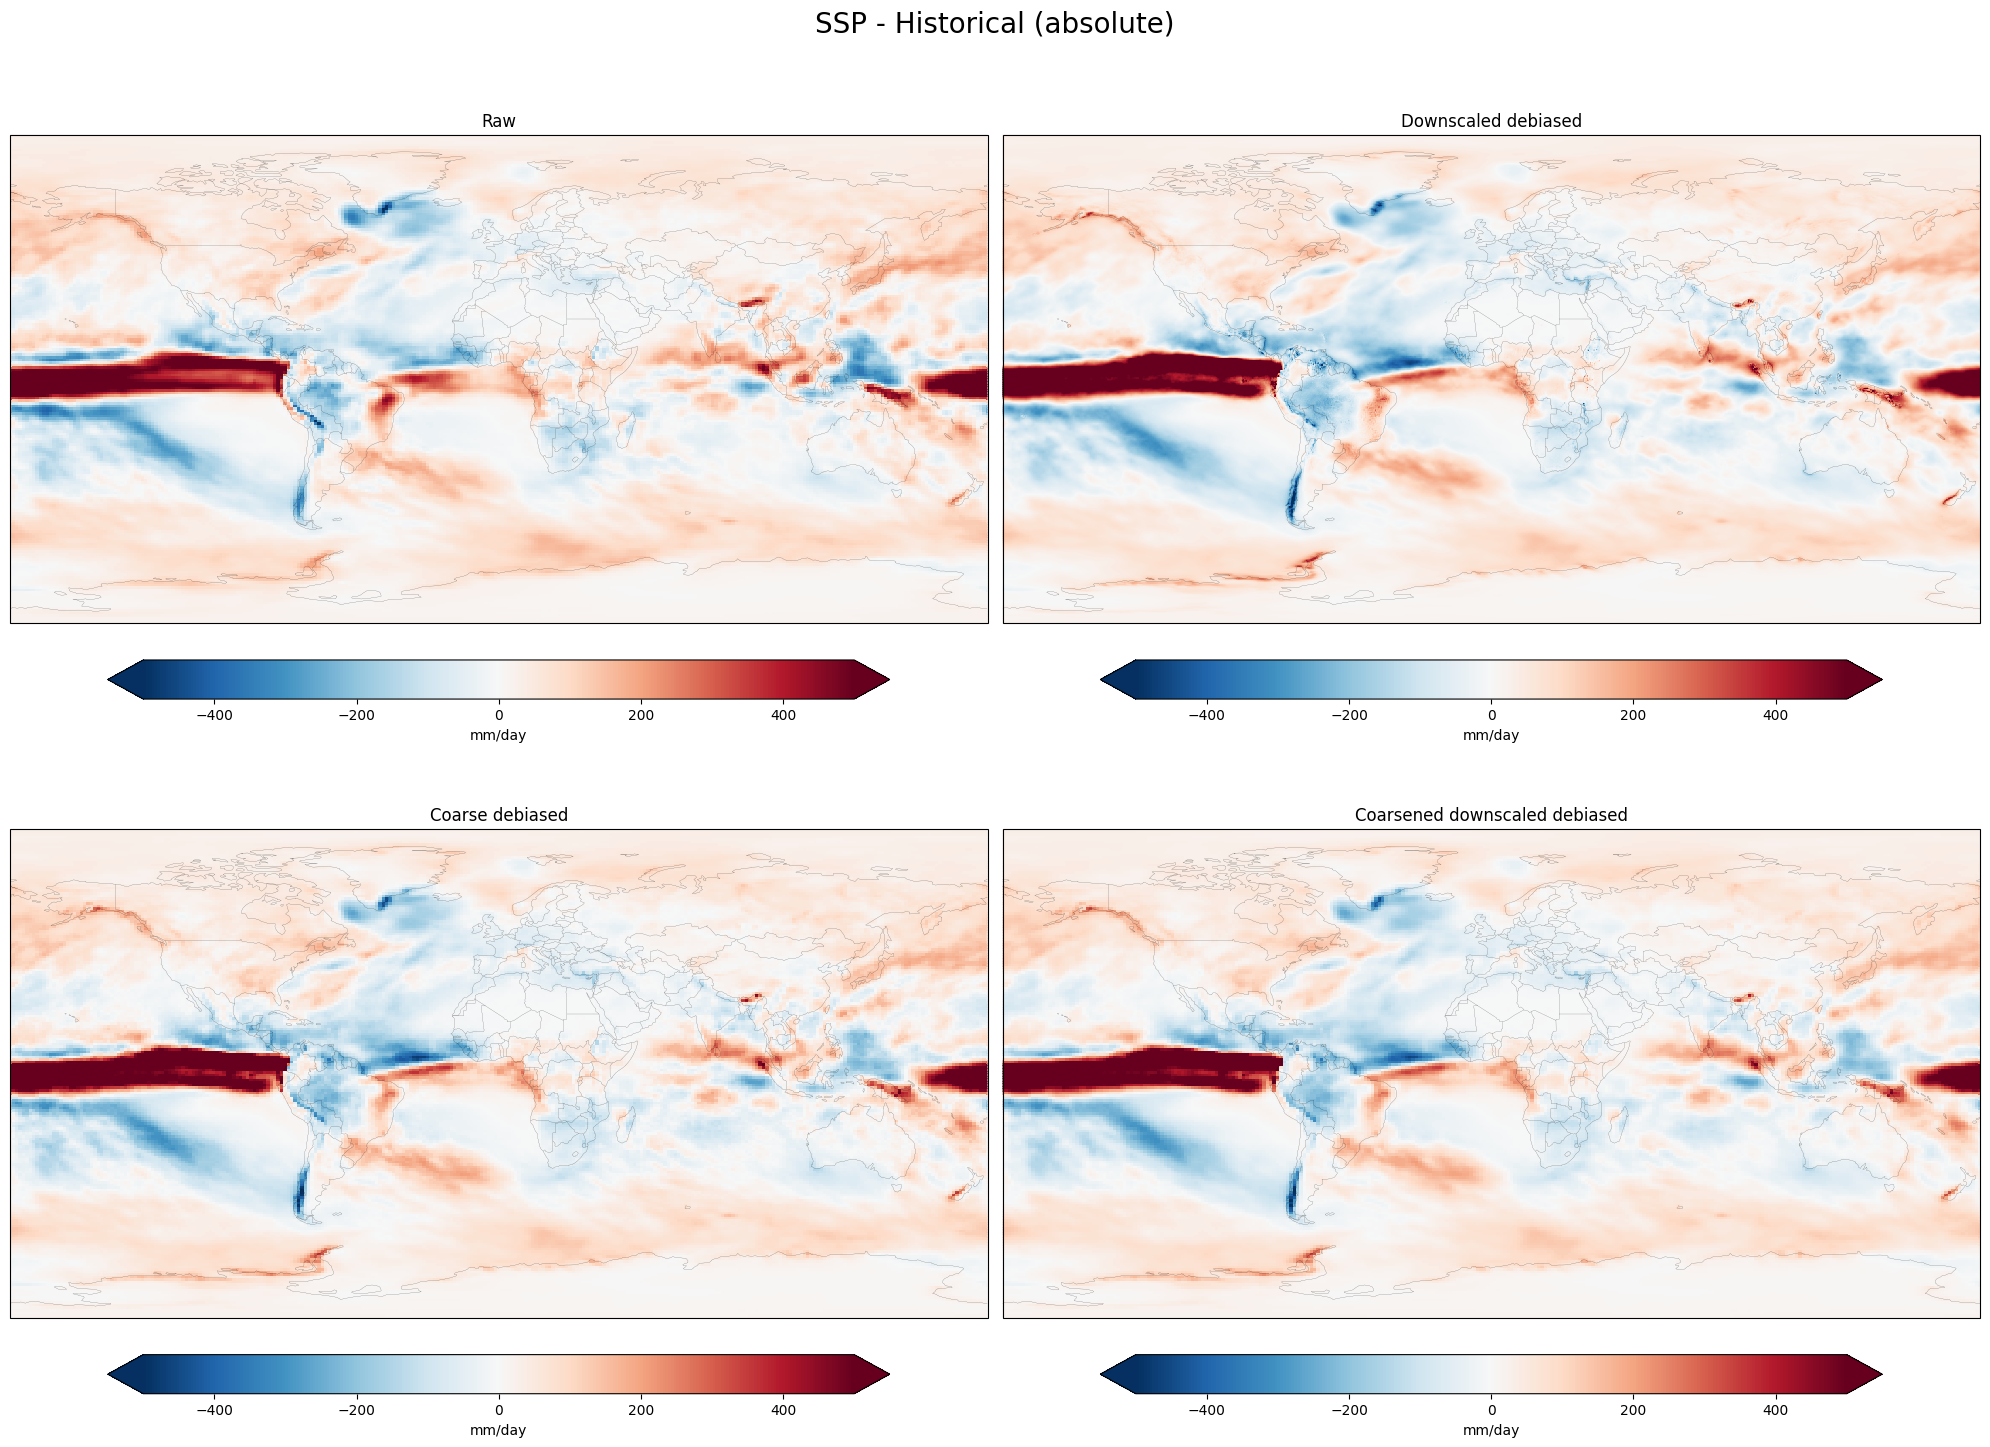

In [74]:
plot_all_deltas(deltas_dict=deltas_ssp_hist, suptitle="SSP - Historical (absolute)", vmax=500)

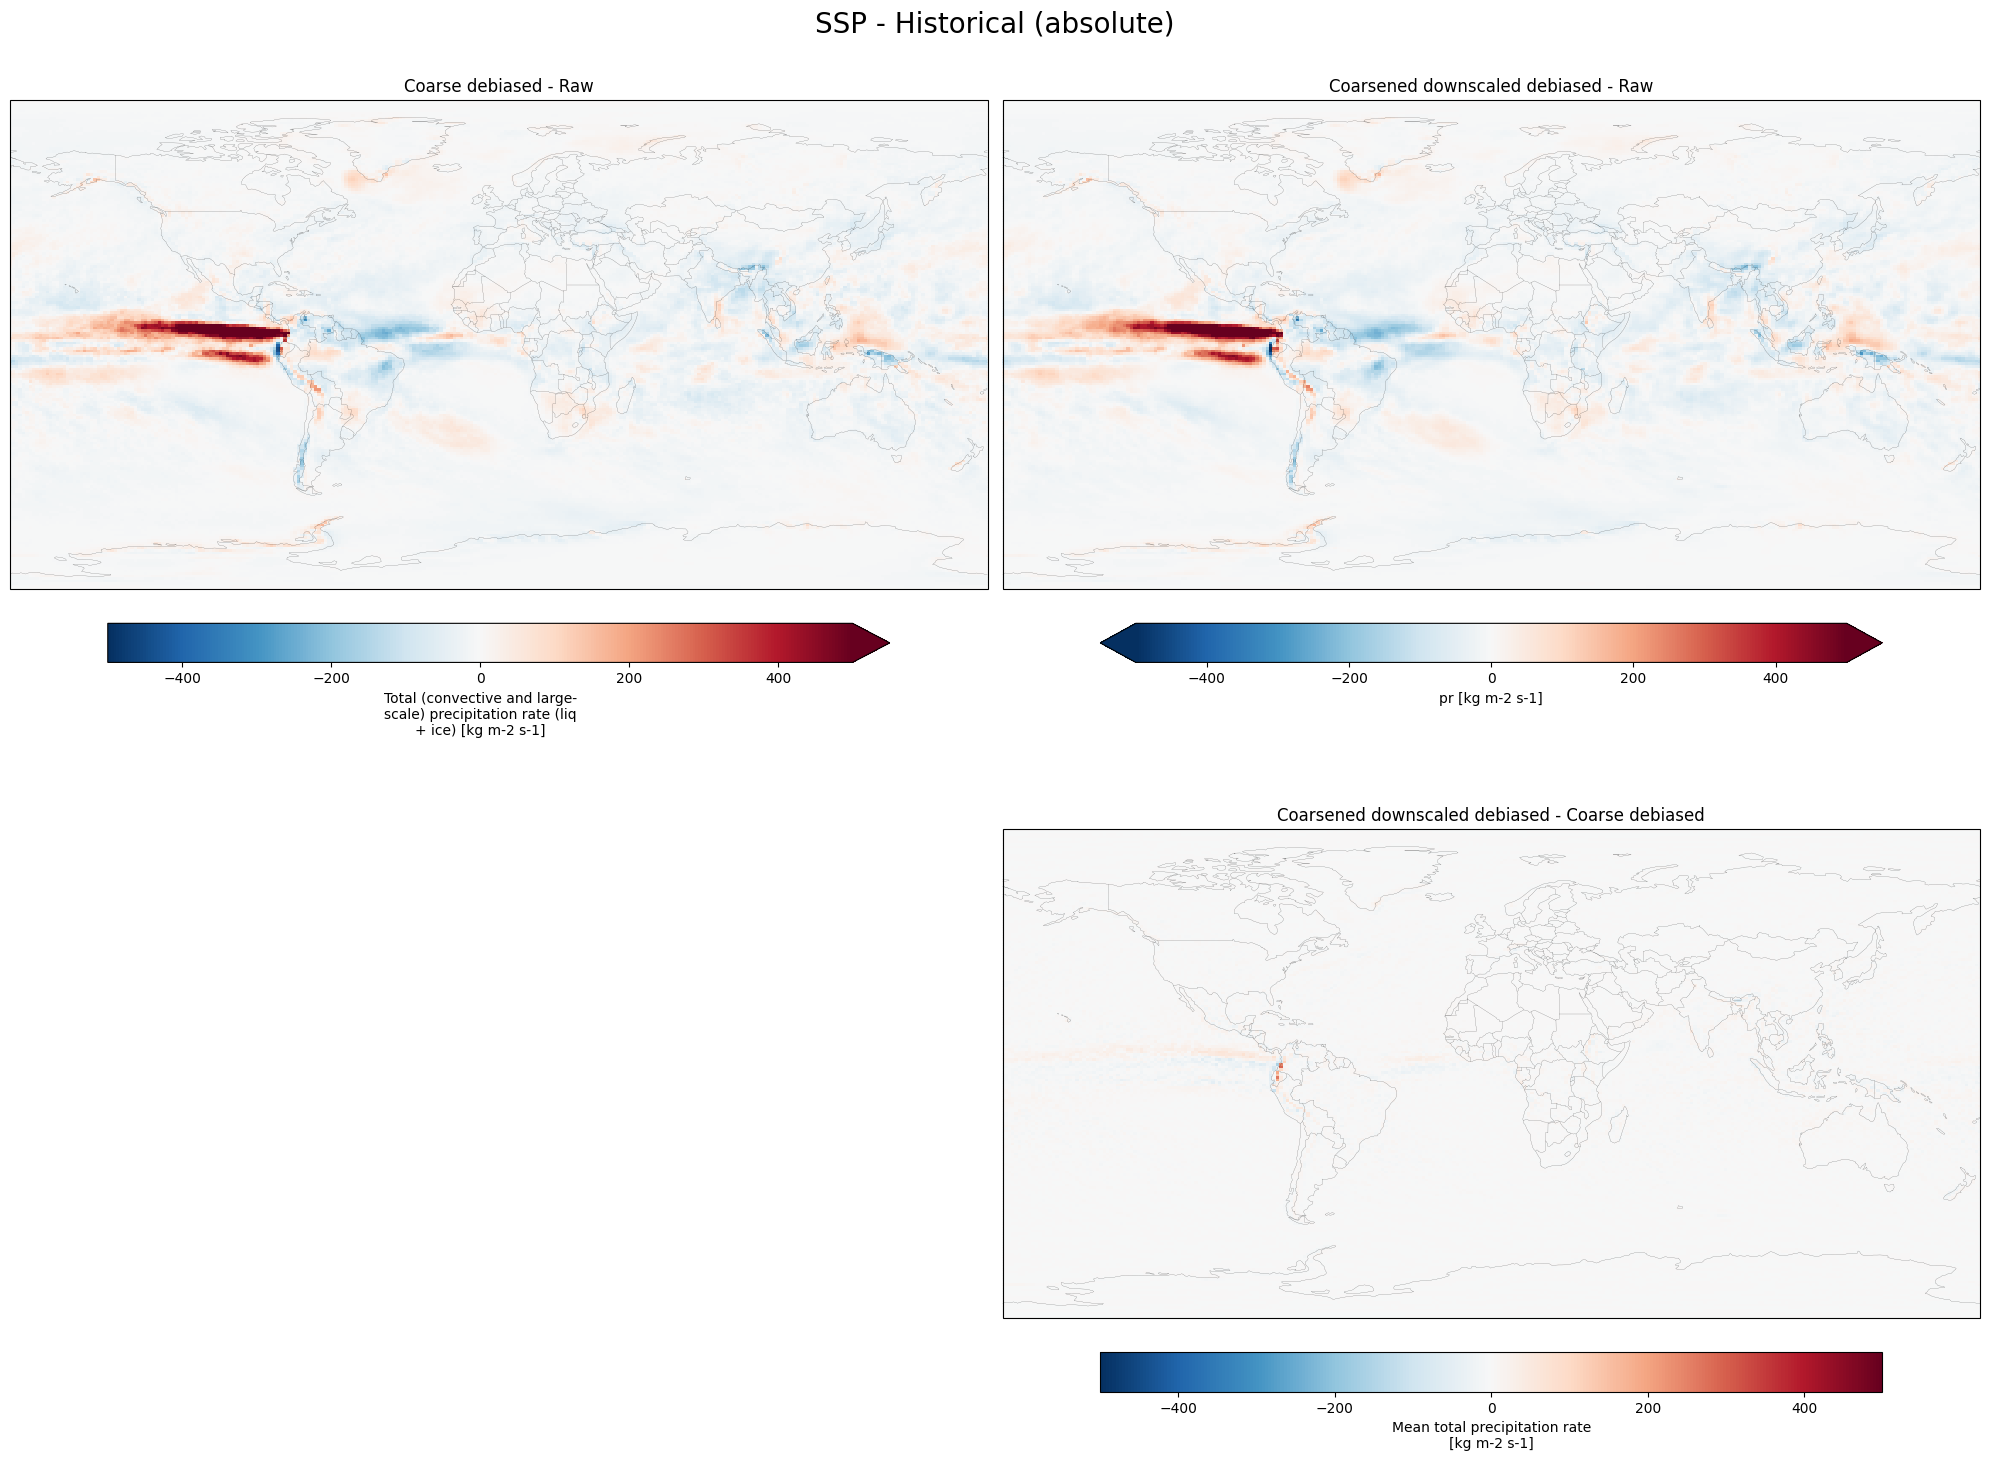

In [75]:
plot_delta_distortions(deltas_ssp_hist, vmax=500, suptitle="SSP - Historical (absolute)")

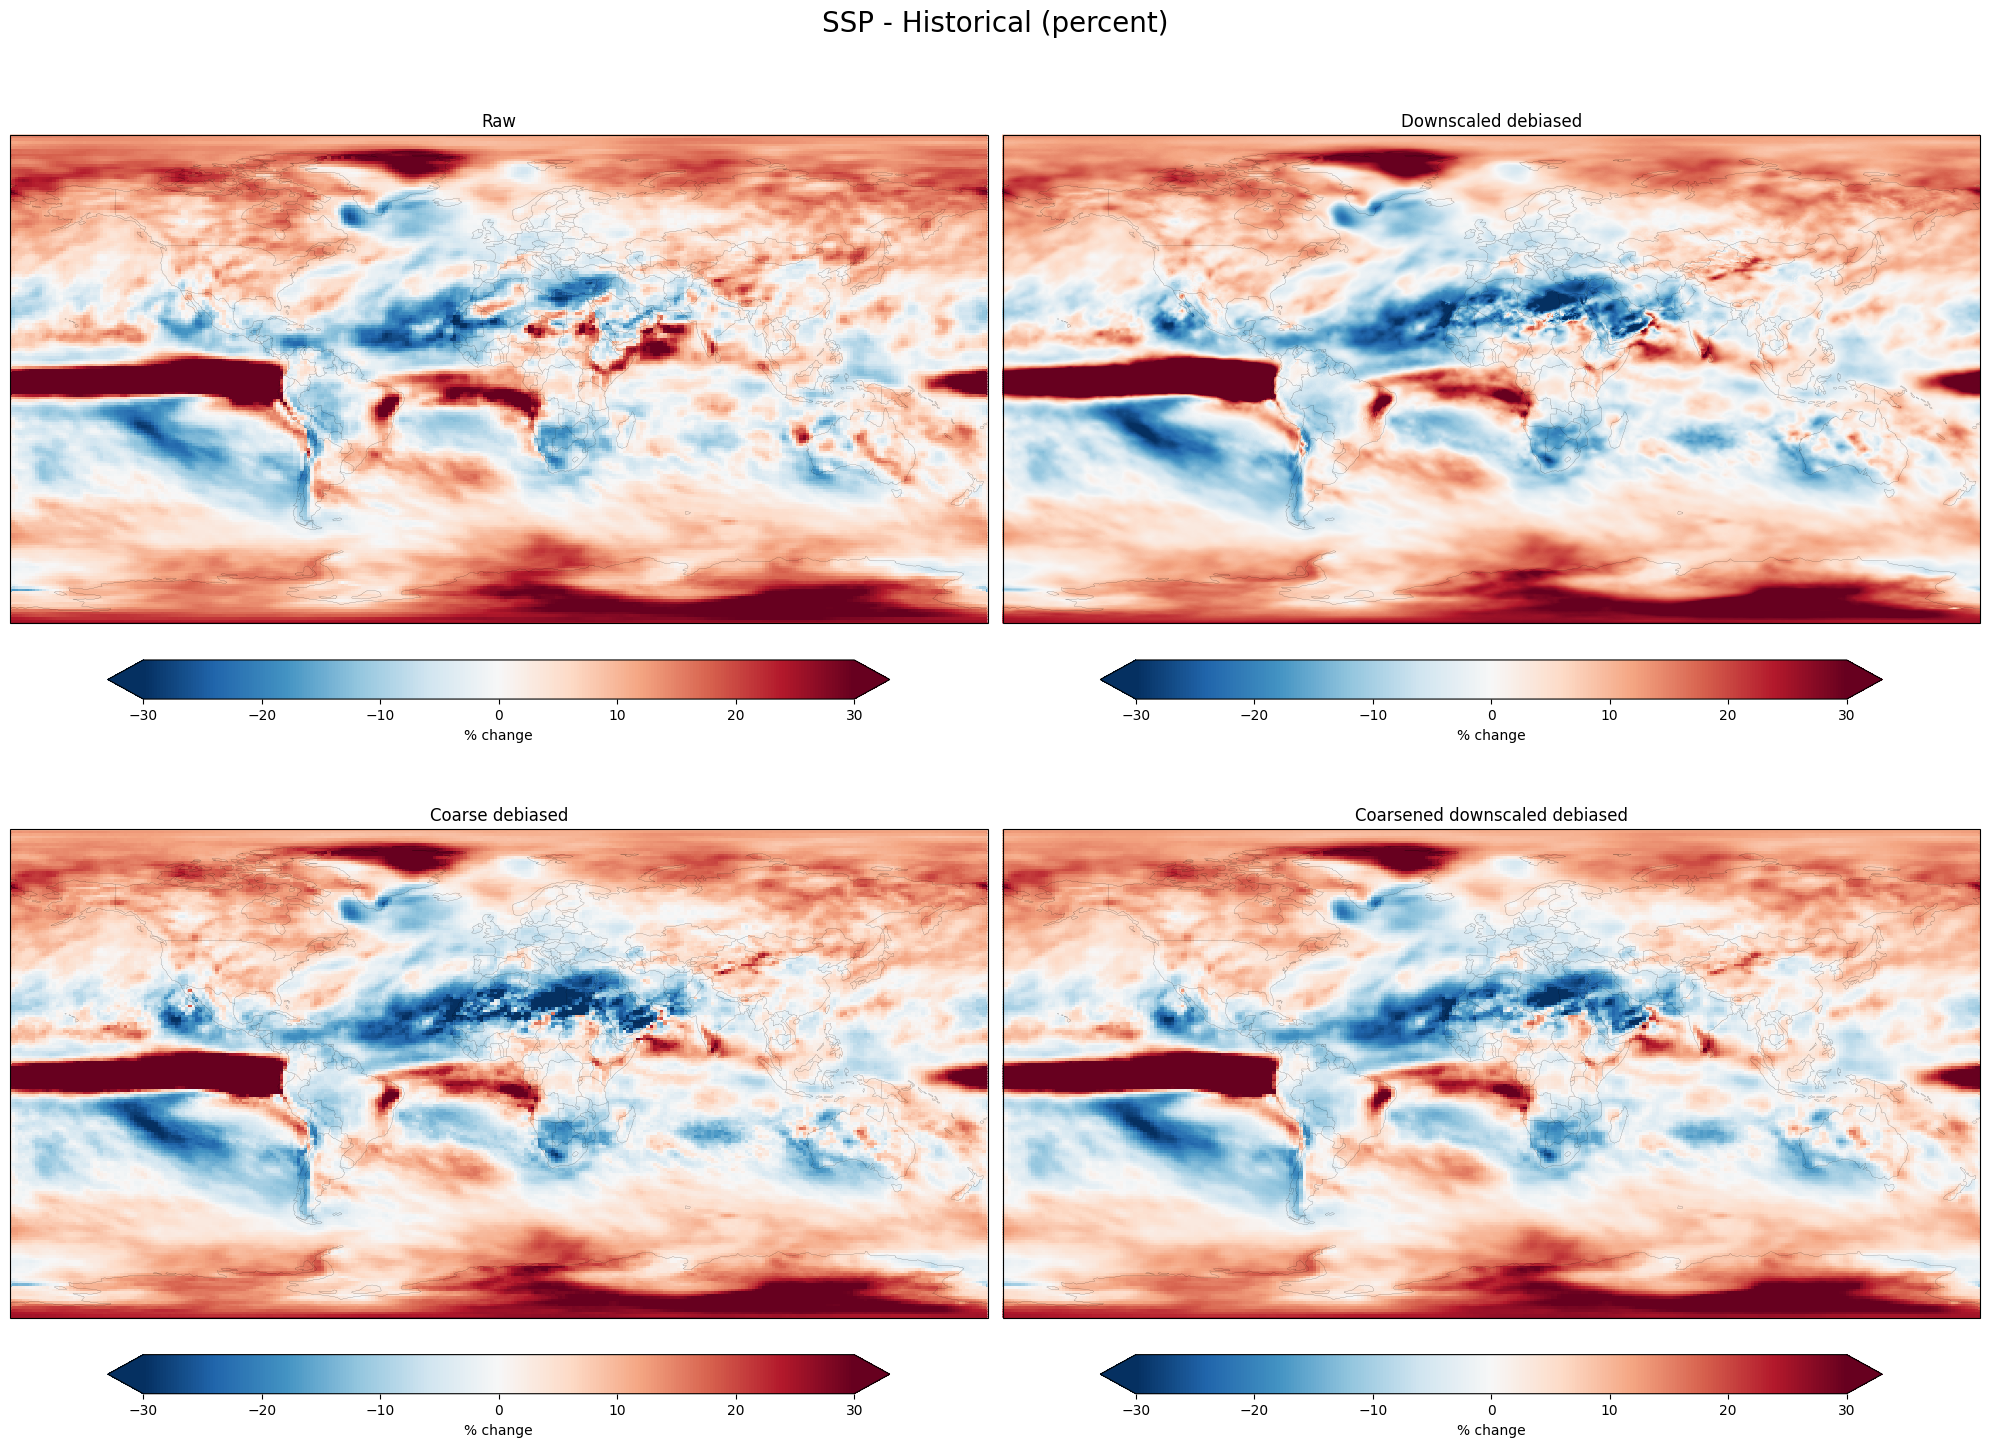

In [76]:
plot_all_deltas(
    deltas_dict=deltas_ssp_hist_pct,
    vmax=30,
    suptitle="SSP - Historical (percent)",
    cbar_label="% change",
)

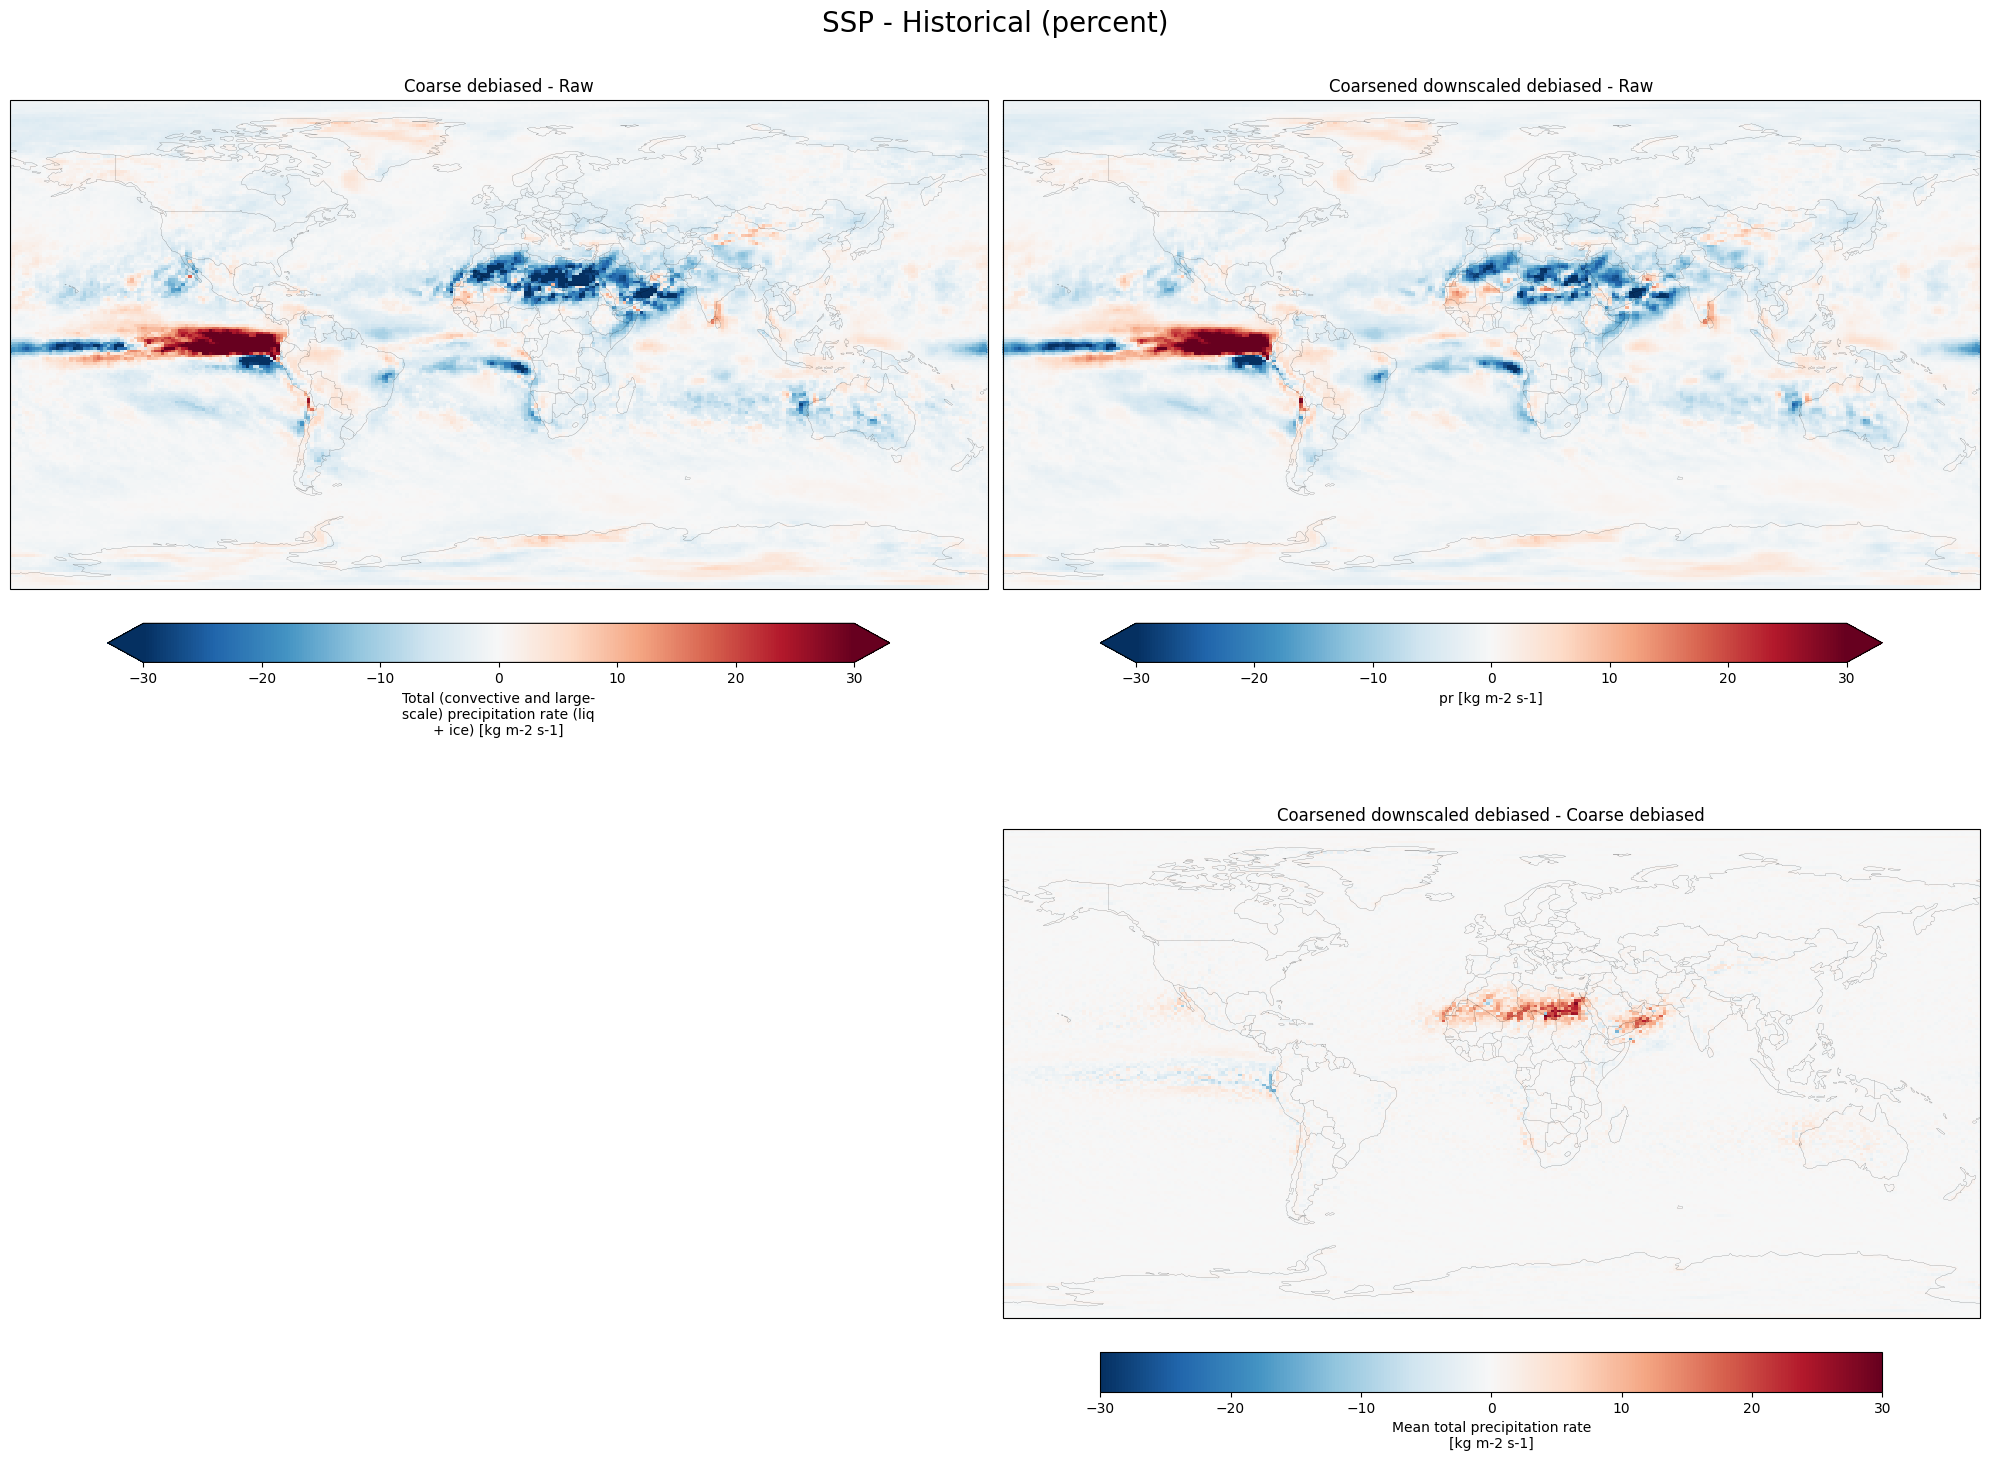

In [77]:
plot_delta_distortions(
    deltas_dict=deltas_ssp_hist_pct,
    vmax=30,
    suptitle="SSP - Historical (percent)",
    cbar_label="% change",
)

## G6 SSP245 differences

In [61]:
deltas_g6_ssp = {
    "raw": raw_delta_g6_ssp,
    "downscaled_debiased": ds_debiased_delta_g6_ssp,
    "coarse_debiased": coarse_debiased_delta_g6_ssp,
    "coarsened_downscaled_debiased": coarsened_ds_debiased_delta_g6_ssp,
}

deltas_g6_ssp_pct = {
    "raw": raw_delta_g6_ssp_pct,
    "downscaled_debiased": ds_debiased_delta_g6_ssp_pct,
    "coarse_debiased": coarse_debiased_delta_g6_ssp_pct,
    "coarsened_downscaled_debiased": coarsened_ds_debiased_delta_g6_ssp_pct,
}

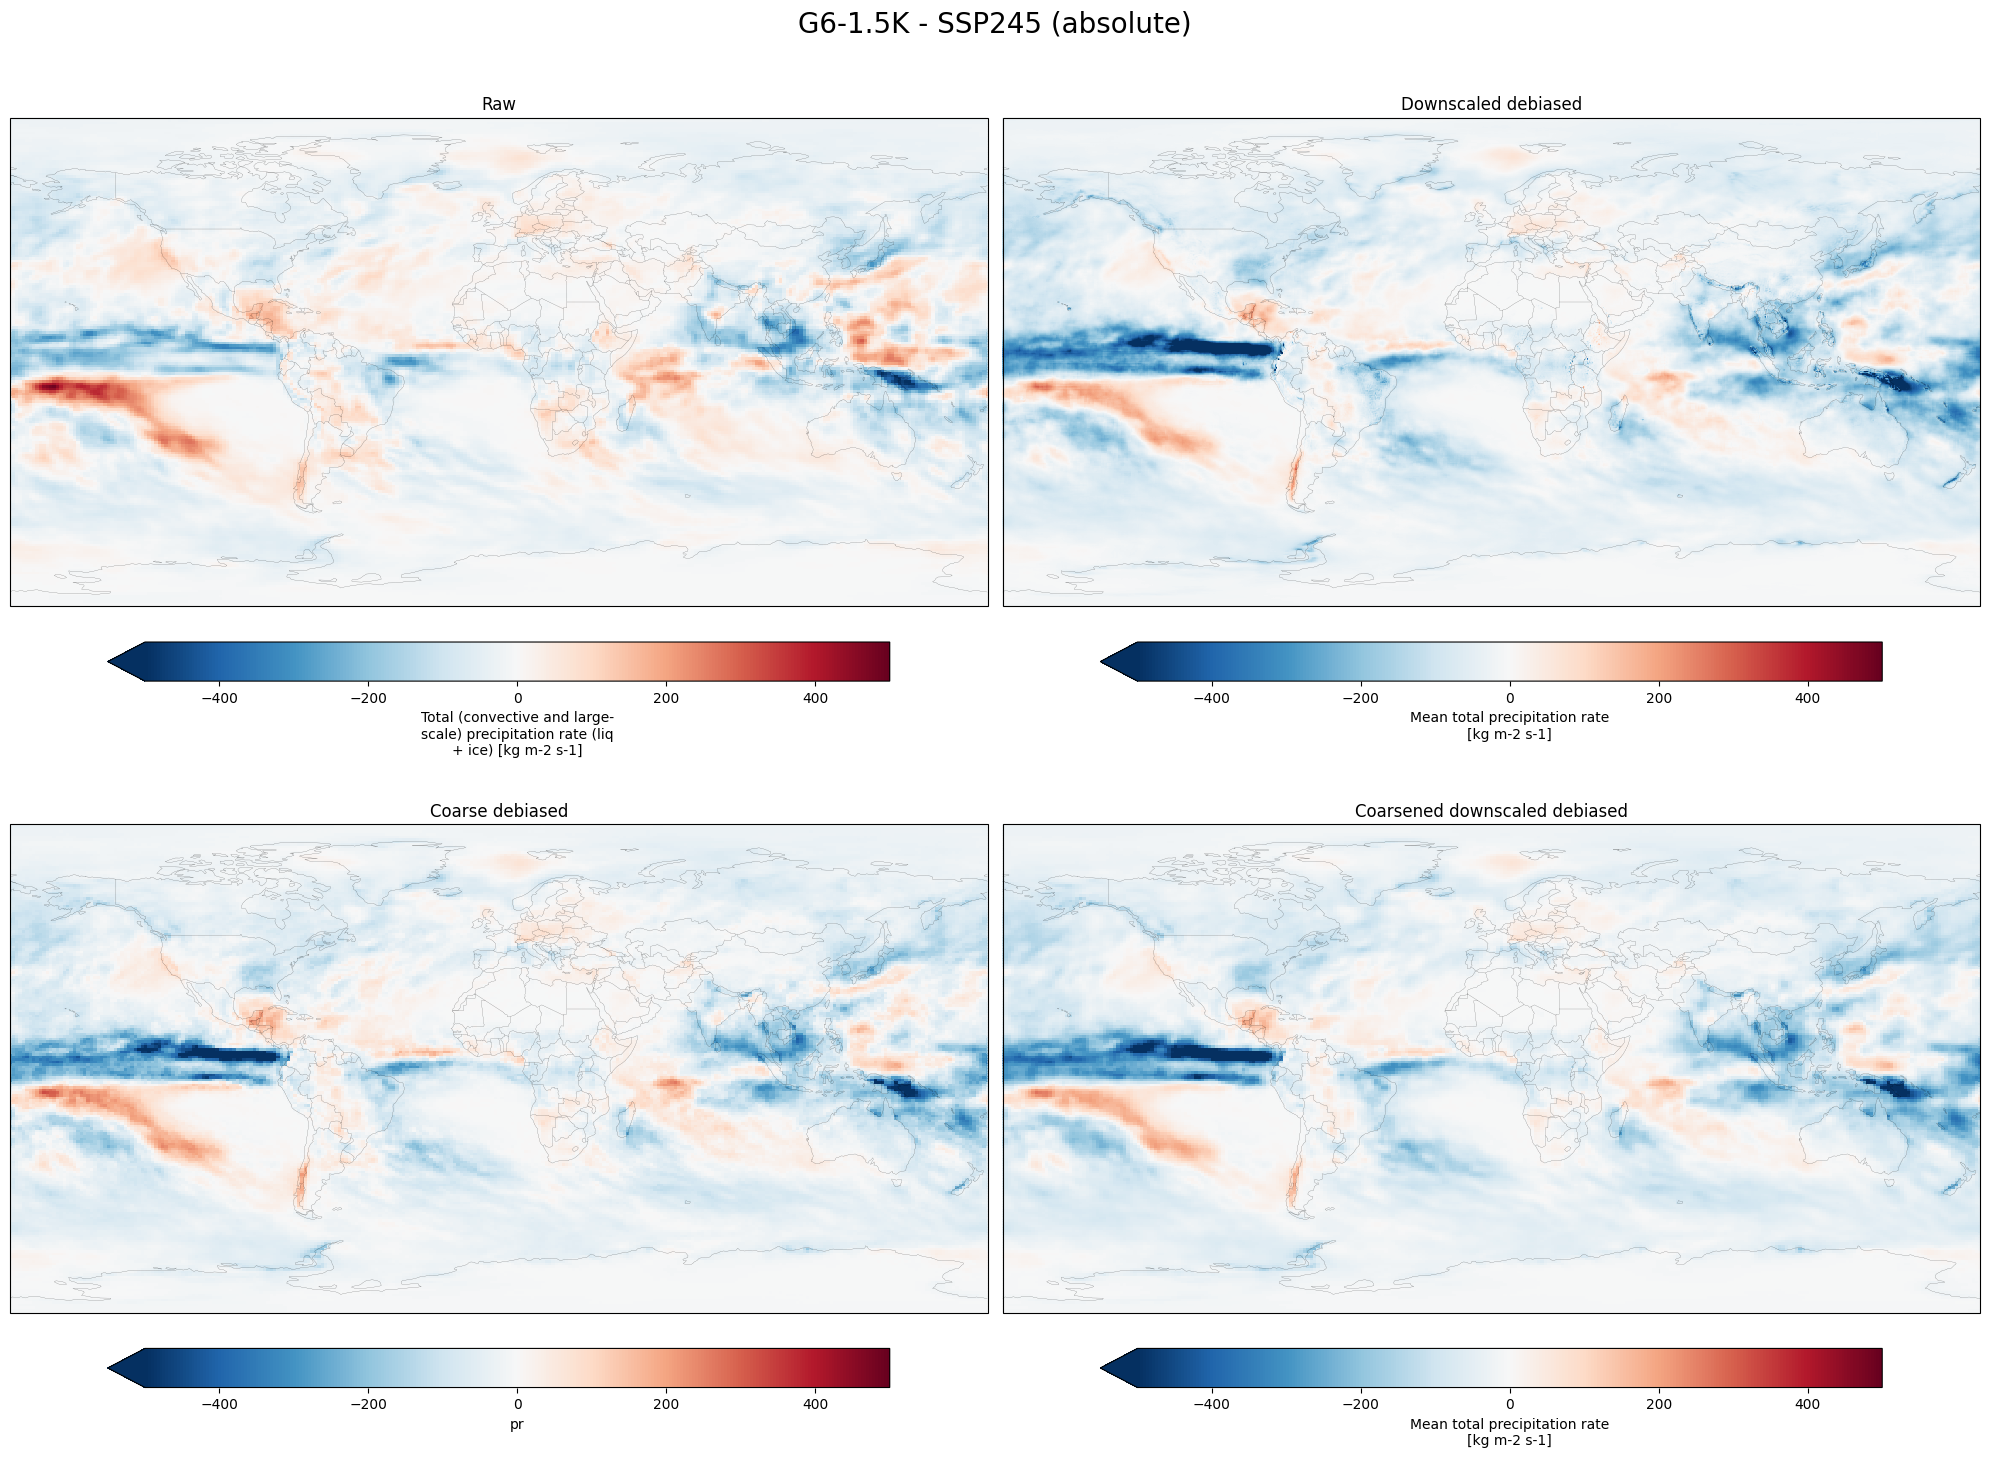

In [63]:
plot_all_deltas(deltas_dict=deltas_g6_ssp, vmax=500, suptitle="G6-1.5K - SSP245 (absolute)")

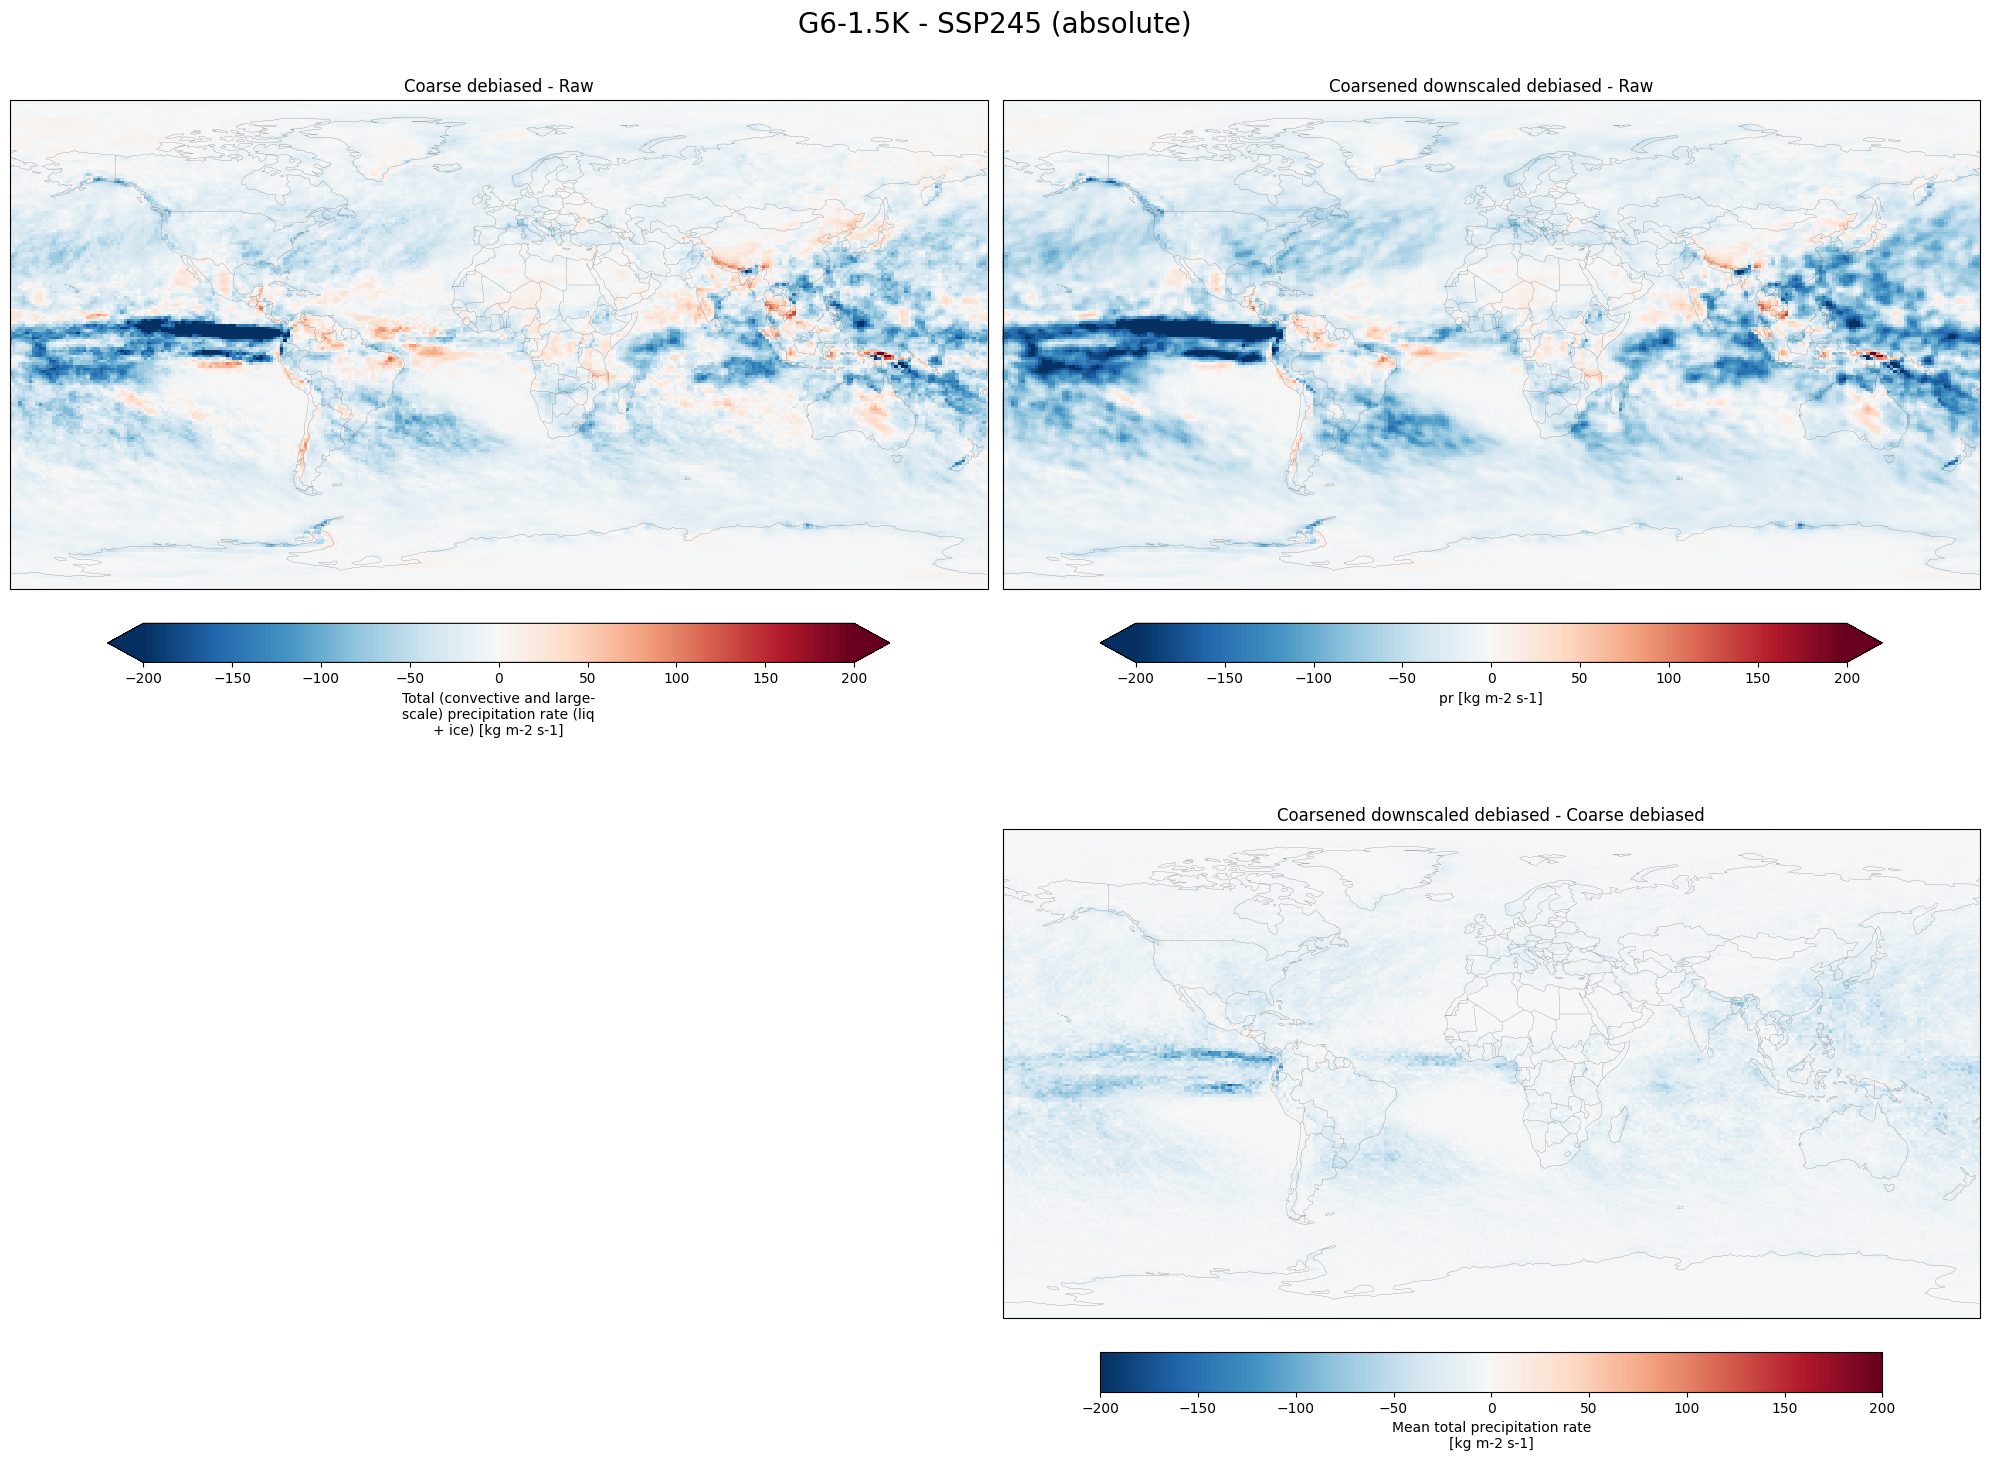

In [66]:
plot_delta_distortions(deltas_g6_ssp, vmax=200, suptitle="G6-1.5K - SSP245 (absolute)")

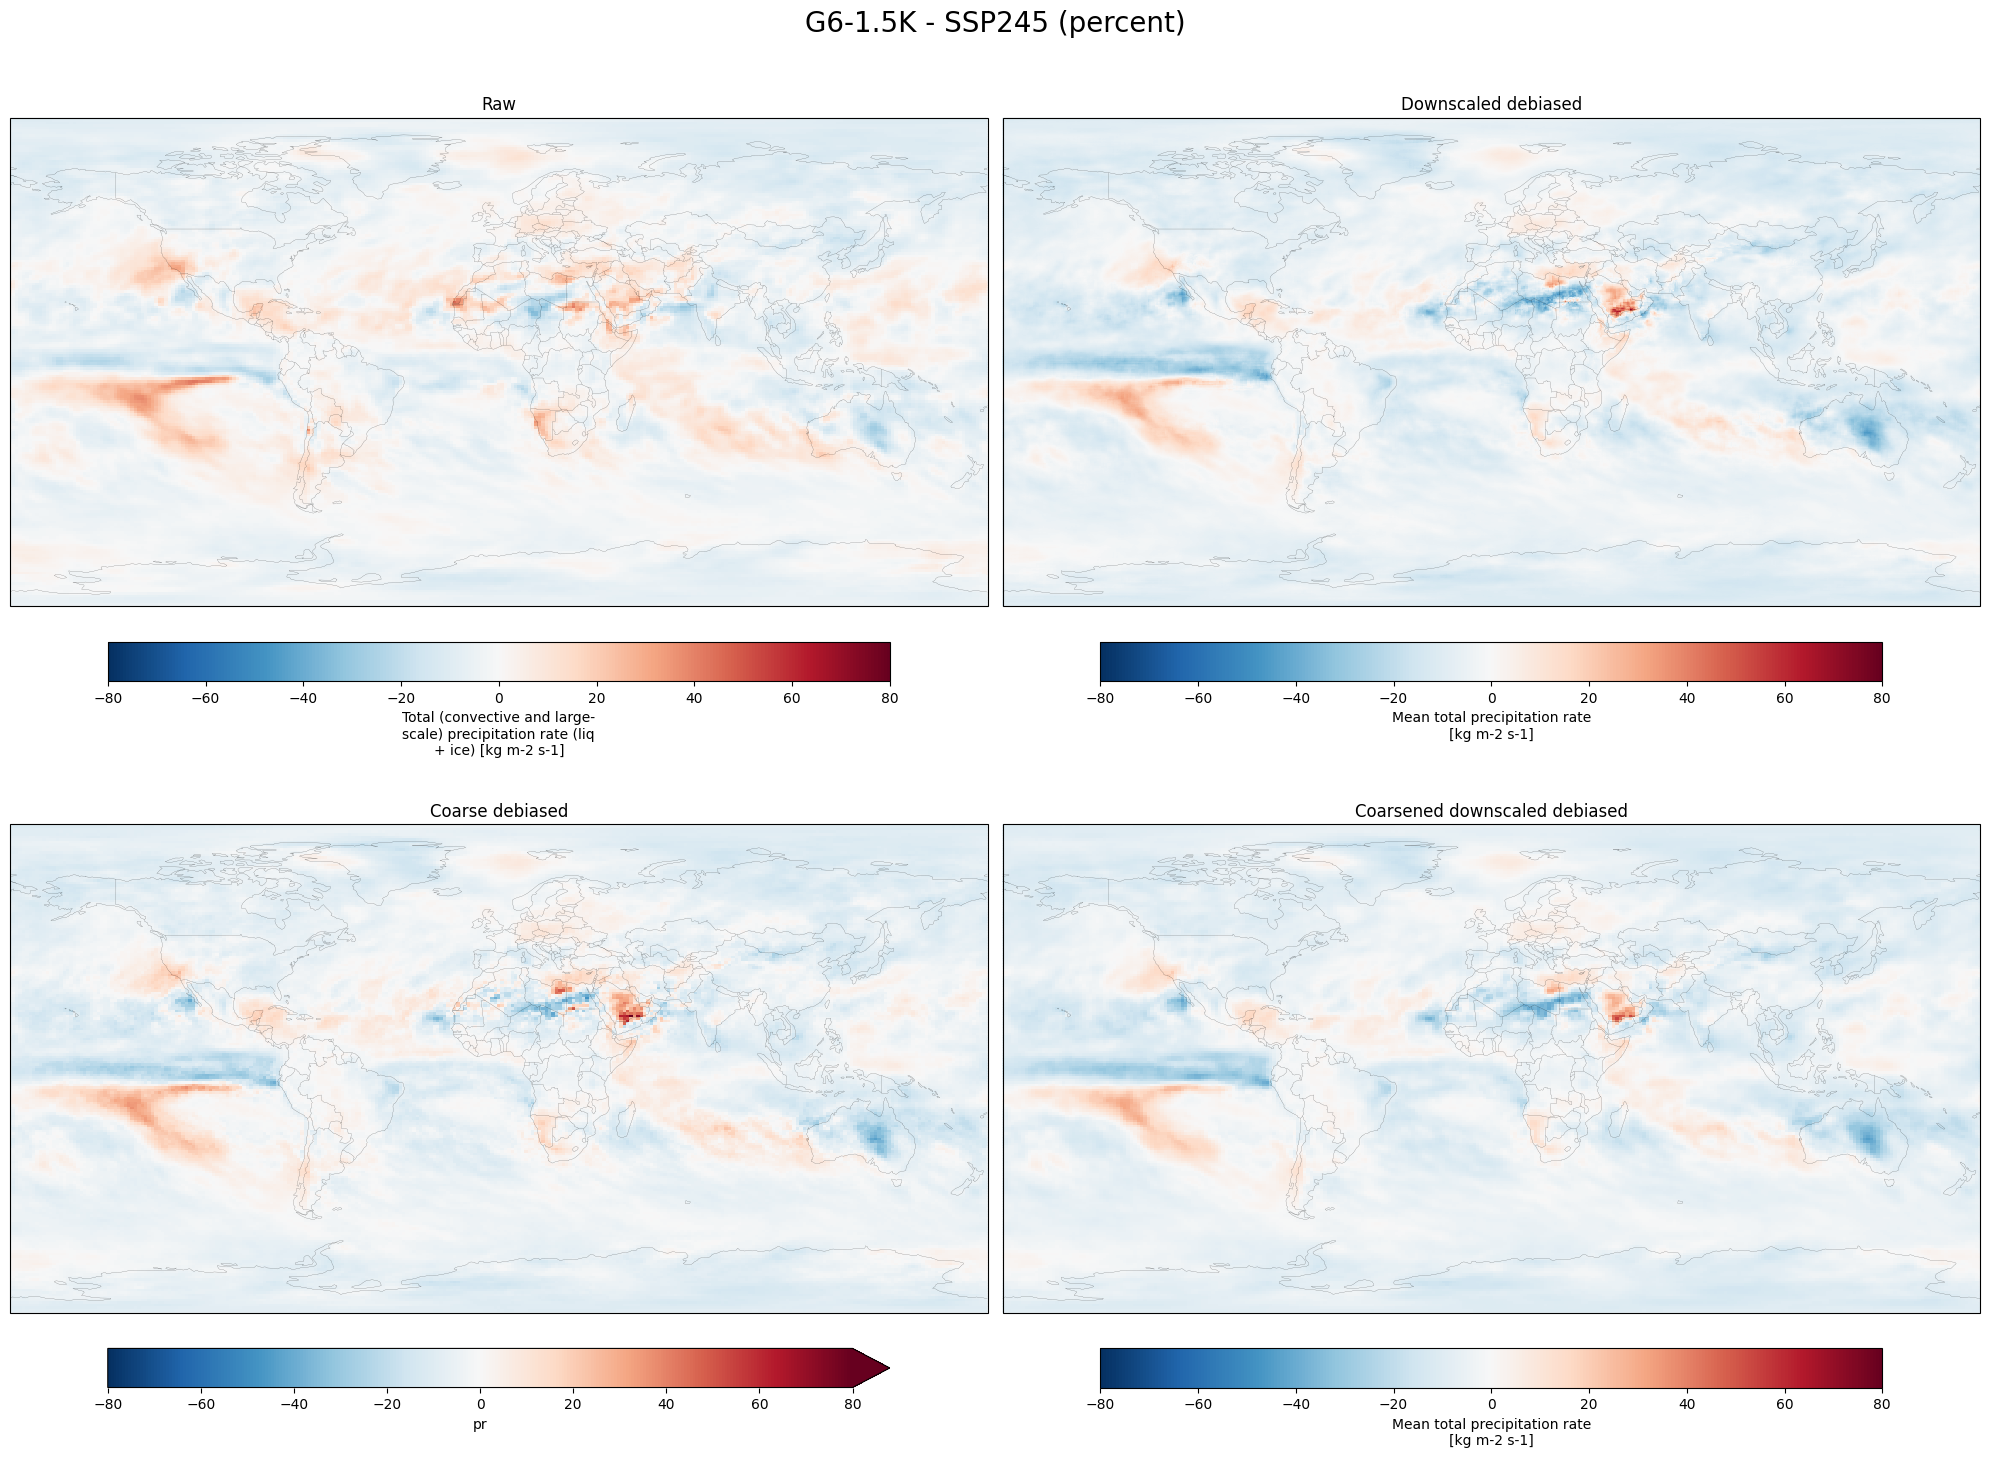

In [67]:
plot_all_deltas(deltas_dict=deltas_g6_ssp_pct, vmax=80, suptitle="G6-1.5K - SSP245 (percent)")

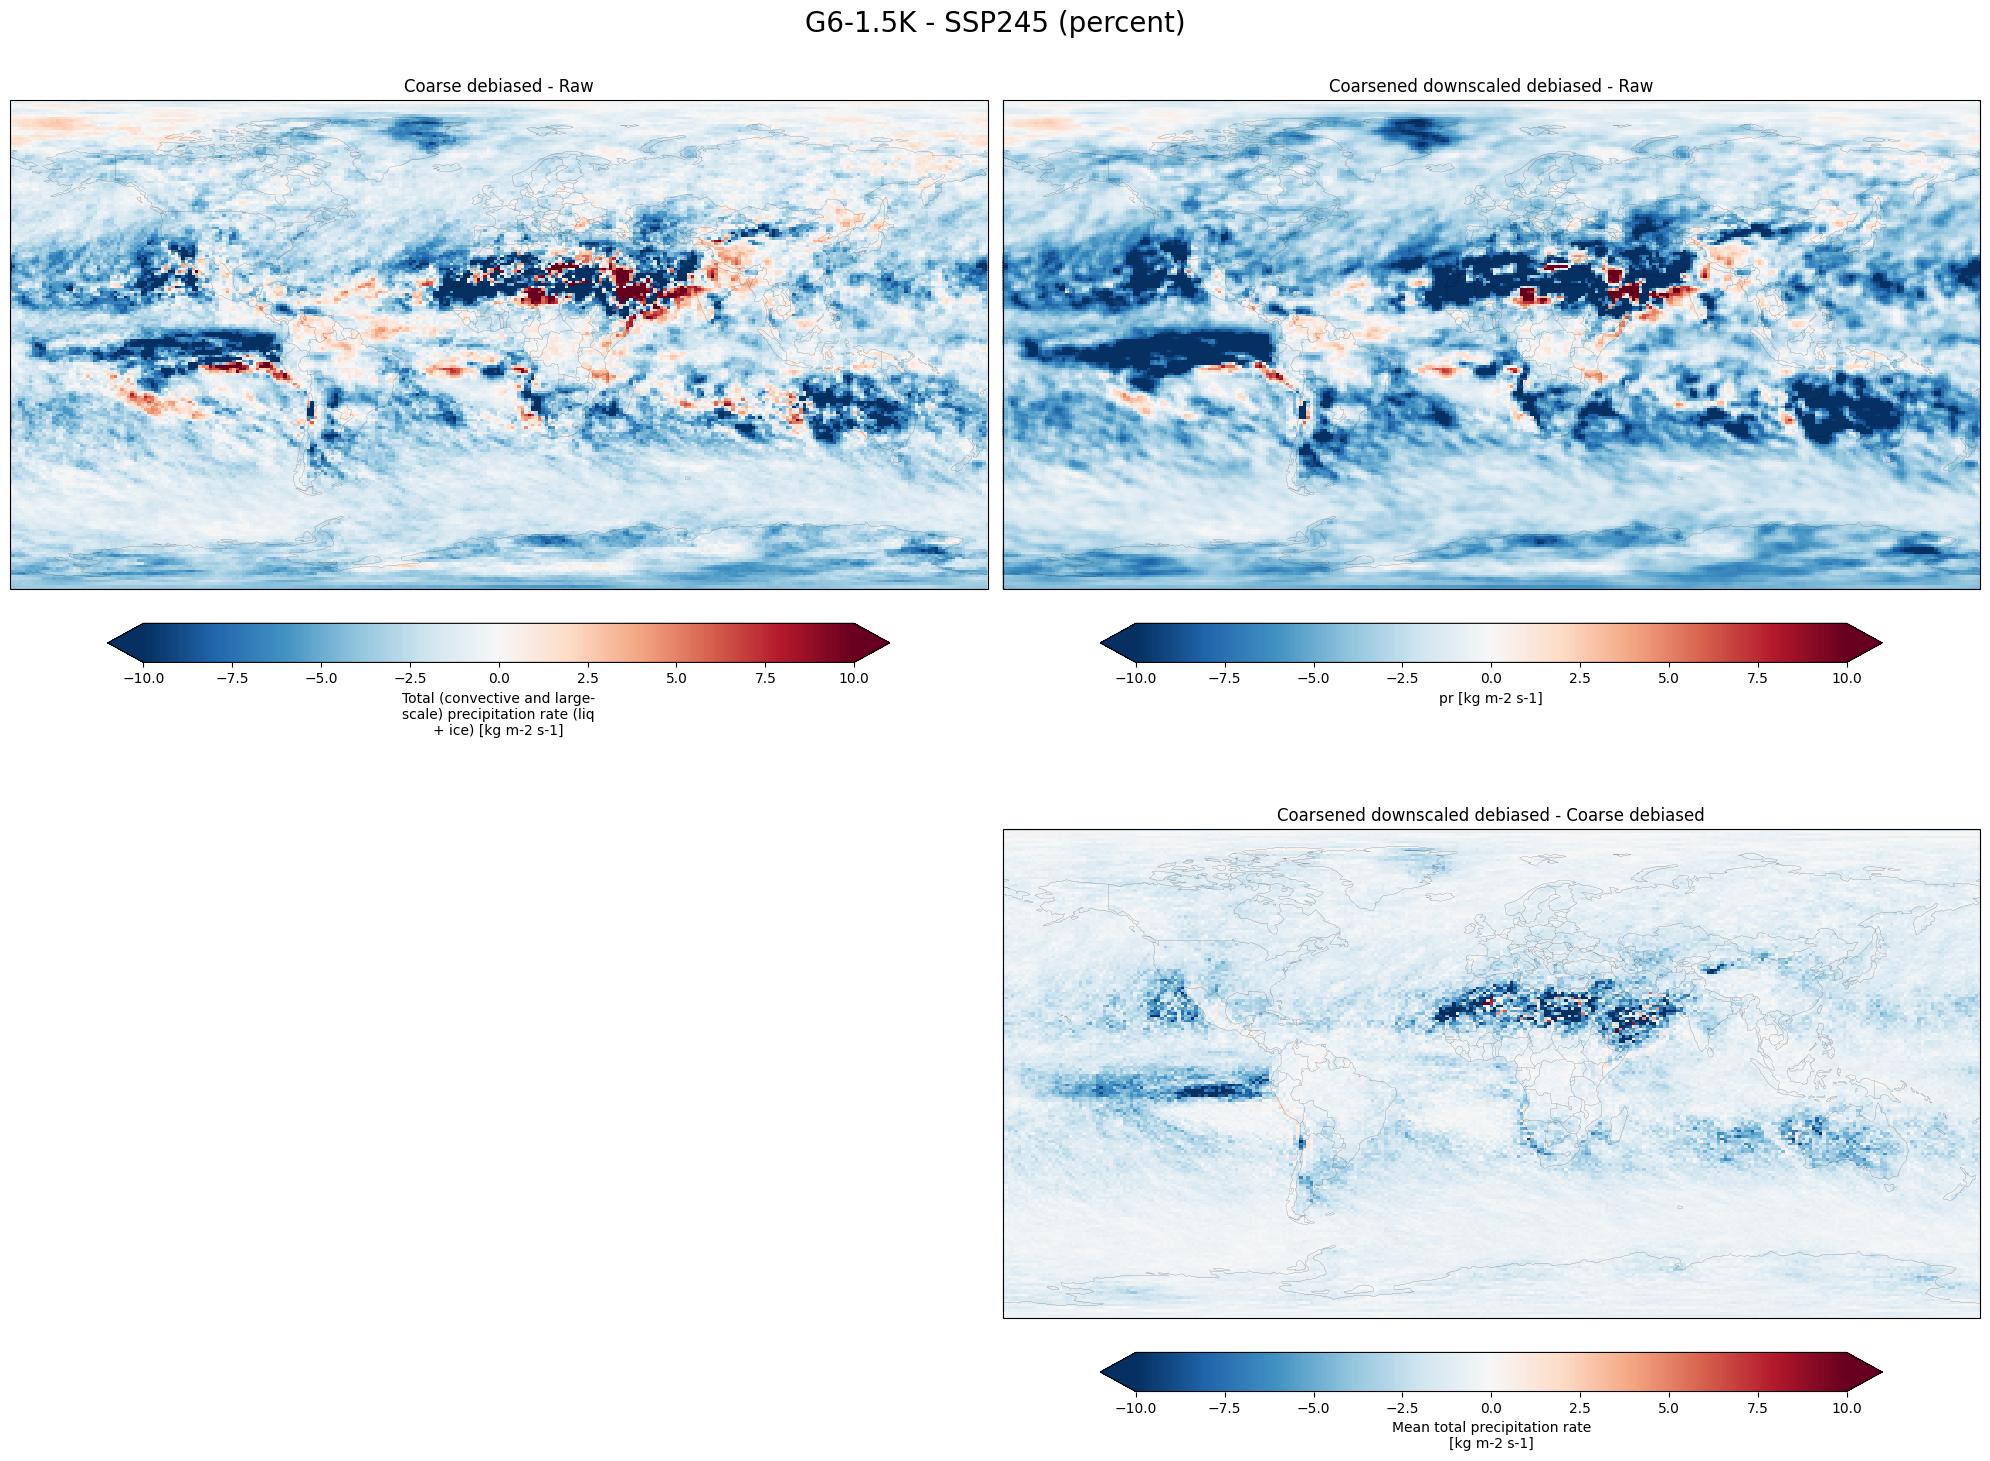

In [69]:
plot_delta_distortions(
    deltas_dict=deltas_g6_ssp_pct, vmax=10, suptitle="G6-1.5K - SSP245 (percent)"
)